In [1]:
from pathlib import Path
from dvrptw_bench.data.der_template_builder import template_dict_from_vrptw_instance
from dvrptw_bench.data.instance_filters import find_c_instances, find_rc_instances
from dvrptw_bench.data.solomon_parser import parse_solomon

from dvrptw_bench.data.solomon_parser import parse_solomon
NUM_CUSTOMERS = 20
# Create templates for RC family
datasetRoot = Path("../dataset/solomon_rc100")
CDatasetRoot = Path("../dataset/solomon_c100")
instances = [parse_solomon(instance, max_customers=NUM_CUSTOMERS) for instance in find_rc_instances(datasetRoot) ] + [parse_solomon(instance, max_customers=NUM_CUSTOMERS) for instance in find_c_instances(CDatasetRoot)]

In [2]:
from dvrptw_bench.data.der_solomon_generator import Family
from dvrptw_bench.data.rl4co_der_generator import FamilySpec
from dvrptw_bench.rl.interfaces import RLPolicy
from dvrptw_bench.rl.rl4co_policy import RL4COPolicy
from dvrptw_bench.rl.rl_model import build_attention_model


# mean gap=61%
# mean gap = 67% NORMALIZED, 61%
model = build_attention_model(max_epochs=100,
        num_loc=NUM_CUSTOMERS,
        batch_size=512,
        train_data_size=100_000,
        val_data_size=1000,
        lr=1e-4,
        normalize_coords=False,
        der_templates=None,
        family_specs=None,
        der_seed=123,
        vehicle_penalty=500,
)
# model.train()
model.load("07_attention_model.pt")
policy = RL4COPolicy(model=model)

/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'env' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['env'])`.
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'policy' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['policy'])`.
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of t

In [3]:
# Compare RL with OR Tools
from dvrptw_bench.heuristics.ortools_solver import ORToolsVRPTWSolver
or_solutions = []
rl_solutions = []
solver = ORToolsVRPTWSolver()
for instance in instances:
    or_solutions.append(solver.solve(instance, 1))
    rl_solutions.append(policy.infer_instance(instance))


Note: RL reported total_distance differs from recomputed route distance.
Mean RL reported total_distance:   419.41
Mean RL recomputed total_distance: 412.94
Instances compared: 17
Mean OR-Tools cost: 221.94
Mean RL cost:       412.94
Mean gap (RL-OR)%:  95.12%
Median gap%:        89.89%
RL better (<0%):    0
OR better (>0%):    17
Ties (~0%):         0


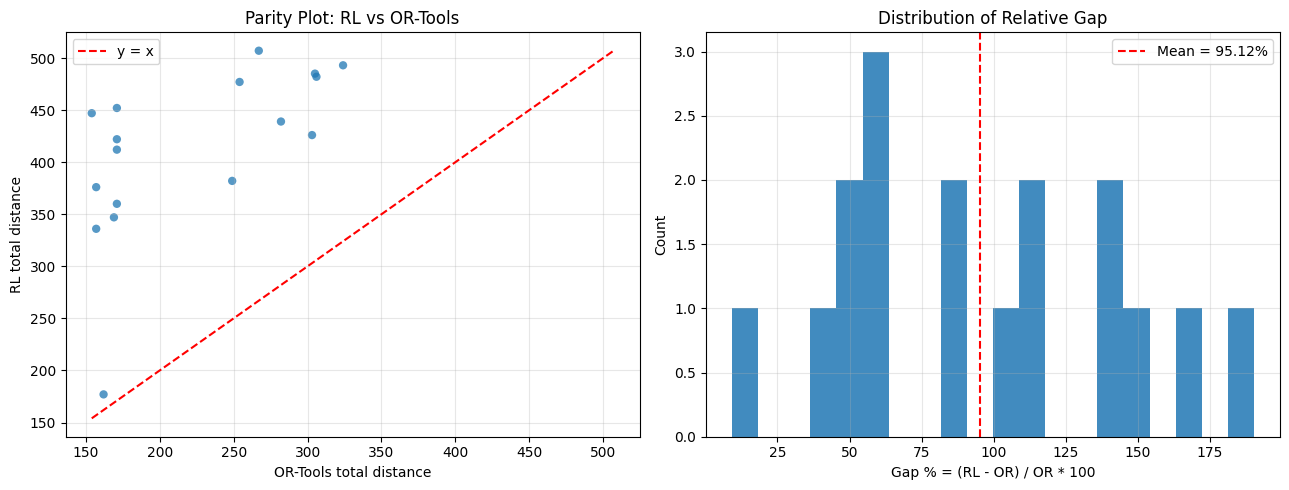

In [4]:
# Compare OR-Tools vs RL inference results (recomputed objective distance)
import numpy as np
import matplotlib.pyplot as plt
from dvrptw_bench.metrics.objective import total_distance

def _safe_reported_cost(solution_or_cost):
    return float(getattr(solution_or_cost, "total_distance", solution_or_cost))

assert len(instances) == len(or_solutions) == len(rl_solutions), (
    "instances, or_solutions, and rl_solutions must have the same length."
)

# Recompute objective distance from routes for a fair comparison.
ort_costs = np.array([total_distance(inst, sol) for inst, sol in zip(instances, or_solutions)], dtype=float)
rl_costs = np.array([total_distance(inst, sol) for inst, sol in zip(instances, rl_solutions)], dtype=float)

# Optional diagnostics for reported RL values vs recomputed objective values.
rl_reported = np.array([_safe_reported_cost(sol) for sol in rl_solutions], dtype=float)
if not np.allclose(rl_reported, rl_costs, rtol=1e-5, atol=1e-5):
    print("Note: RL reported total_distance differs from recomputed route distance.")
    print(f"Mean RL reported total_distance:   {rl_reported.mean():.2f}")
    print(f"Mean RL recomputed total_distance: {rl_costs.mean():.2f}")

eps = 1e-9
gap_pct = (rl_costs - ort_costs) / np.maximum(ort_costs, eps) * 100.0

print(f"Instances compared: {len(ort_costs)}")
print(f"Mean OR-Tools cost: {ort_costs.mean():.2f}")
print(f"Mean RL cost:       {rl_costs.mean():.2f}")
print(f"Mean gap (RL-OR)%:  {gap_pct.mean():.2f}%")
print(f"Median gap%:        {np.median(gap_pct):.2f}%")
print(f"RL better (<0%):    {np.sum(gap_pct < 0)}")
print(f"OR better (>0%):    {np.sum(gap_pct > 0)}")
print(f"Ties (~0%):         {np.sum(np.isclose(gap_pct, 0.0, atol=1e-6))}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Parity plot (RL vs OR-Tools).
axes[0].scatter(ort_costs, rl_costs, alpha=0.75, edgecolor="none")
lo = float(min(ort_costs.min(), rl_costs.min()))
hi = float(max(ort_costs.max(), rl_costs.max()))
axes[0].plot([lo, hi], [lo, hi], "r--", linewidth=1.5, label="y = x")
axes[0].set_xlabel("OR-Tools total distance")
axes[0].set_ylabel("RL total distance")
axes[0].set_title("Parity Plot: RL vs OR-Tools")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Gap distribution.
axes[1].hist(gap_pct, bins=20, alpha=0.85, color="tab:blue")
axes[1].axvline(gap_pct.mean(), color="r", linestyle="--", linewidth=1.5, label=f"Mean = {gap_pct.mean():.2f}%")
axes[1].set_xlabel("Gap % = (RL - OR) / OR * 100")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Relative Gap")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
rl_solutions

[Solution(strategy='rl4co', routes=[Route(vehicle_id=0, node_ids=[5, 2, 7, 8, 3, 1]), Route(vehicle_id=1, node_ids=[14, 9, 13, 17, 4]), Route(vehicle_id=2, node_ids=[19, 18, 20]), Route(vehicle_id=3, node_ids=[15, 16, 12, 11, 10]), Route(vehicle_id=4, node_ids=[6])], total_distance=497.91741943359375, feasible=True, violations={}, solve_time_s=0.0, details={}),
 Solution(strategy='rl4co', routes=[Route(vehicle_id=0, node_ids=[14, 15, 11, 16, 18, 19, 20, 13, 17, 12, 7, 1, 5, 3, 2]), Route(vehicle_id=1, node_ids=[8, 6, 4]), Route(vehicle_id=2, node_ids=[9, 10])], total_distance=432.2745361328125, feasible=True, violations={}, solve_time_s=0.0, details={}),
 Solution(strategy='rl4co', routes=[Route(vehicle_id=0, node_ids=[11, 15, 13, 12, 4, 5, 2, 14, 19, 18, 20]), Route(vehicle_id=1, node_ids=[8, 6]), Route(vehicle_id=2, node_ids=[9, 10, 17, 1, 3, 7, 16])], total_distance=513.6405029296875, feasible=True, violations={}, solve_time_s=0.0, details={}),
 Solution(strategy='rl4co', routes=[Ro

In [6]:
or_solutions

[Solution(strategy='ortools', routes=[Route(vehicle_id=0, node_ids=[]), Route(vehicle_id=1, node_ids=[]), Route(vehicle_id=2, node_ids=[]), Route(vehicle_id=3, node_ids=[]), Route(vehicle_id=4, node_ids=[]), Route(vehicle_id=5, node_ids=[]), Route(vehicle_id=6, node_ids=[]), Route(vehicle_id=7, node_ids=[]), Route(vehicle_id=8, node_ids=[]), Route(vehicle_id=9, node_ids=[]), Route(vehicle_id=10, node_ids=[]), Route(vehicle_id=11, node_ids=[]), Route(vehicle_id=12, node_ids=[]), Route(vehicle_id=13, node_ids=[]), Route(vehicle_id=14, node_ids=[]), Route(vehicle_id=15, node_ids=[]), Route(vehicle_id=16, node_ids=[]), Route(vehicle_id=17, node_ids=[]), Route(vehicle_id=18, node_ids=[]), Route(vehicle_id=19, node_ids=[]), Route(vehicle_id=20, node_ids=[]), Route(vehicle_id=21, node_ids=[18, 19, 20]), Route(vehicle_id=22, node_ids=[2, 5, 8, 7, 6, 3, 1, 4]), Route(vehicle_id=23, node_ids=[]), Route(vehicle_id=24, node_ids=[14, 12, 16, 15, 11, 9, 10, 13, 17])], total_distance=324.0, feasible=

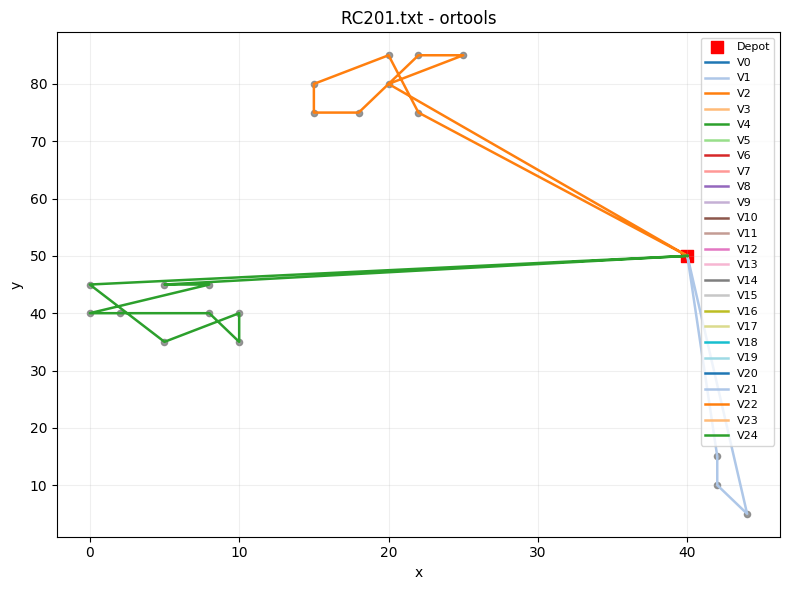

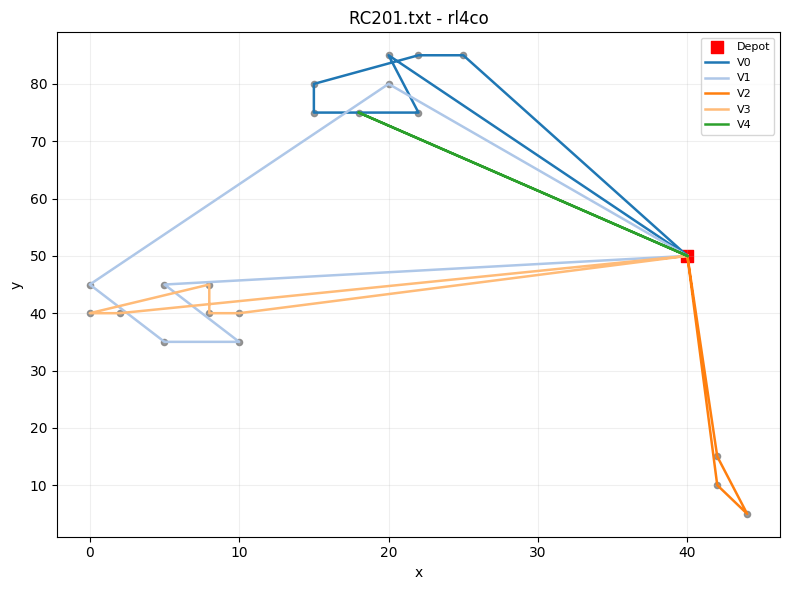

In [7]:
from dvrptw_bench.viz.route_plot import plot_routes
plot_routes(instances[0], or_solutions[0])
plot_routes(instances[0], rl_solutions[0]) 

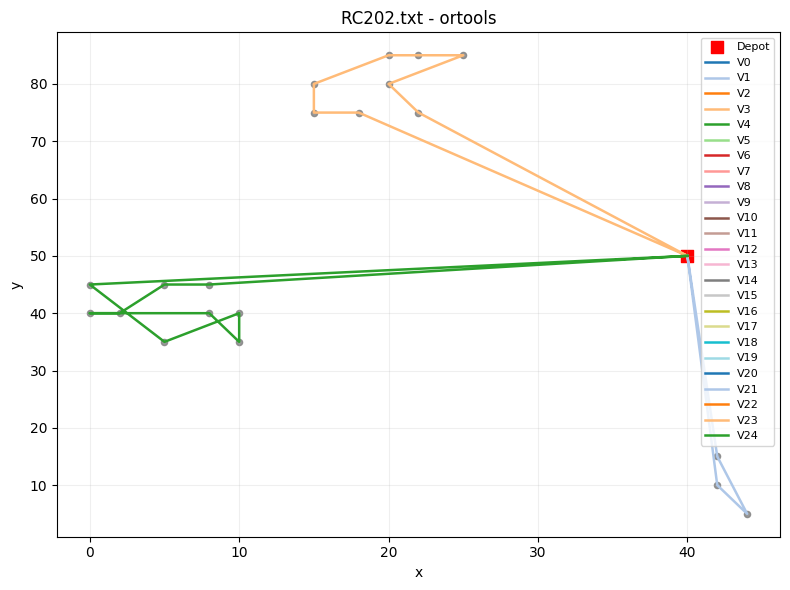

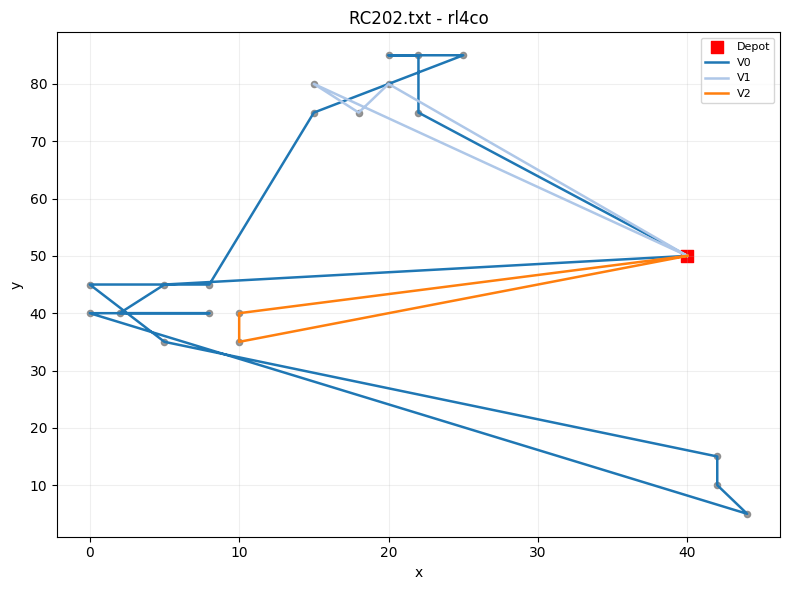

In [8]:

plot_routes(instances[1], or_solutions[1])
plot_routes(instances[1], rl_solutions[1]) 

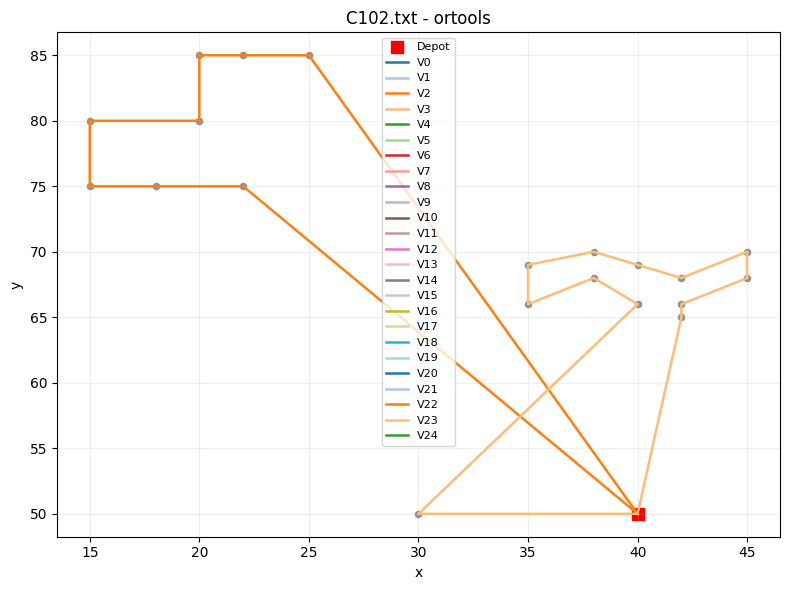

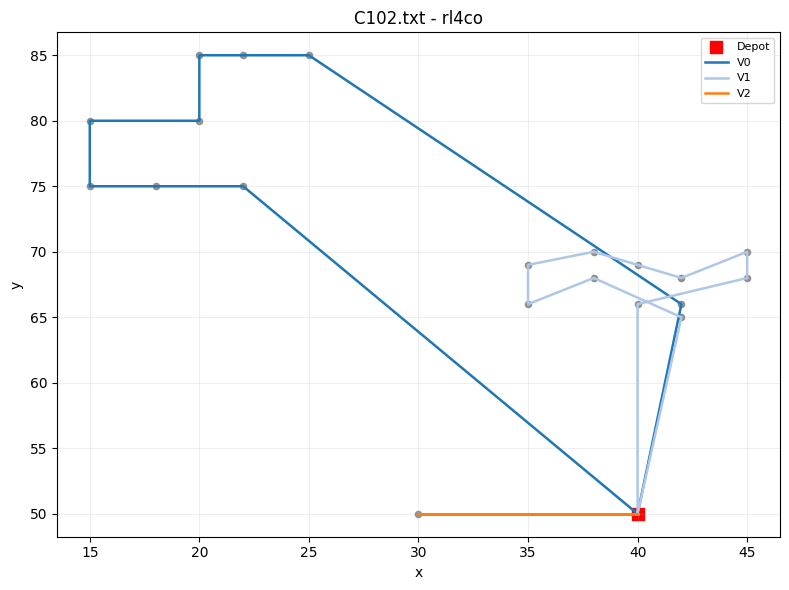

In [9]:

plot_routes(instances[9], or_solutions[9])
plot_routes(instances[9], rl_solutions[9]) 

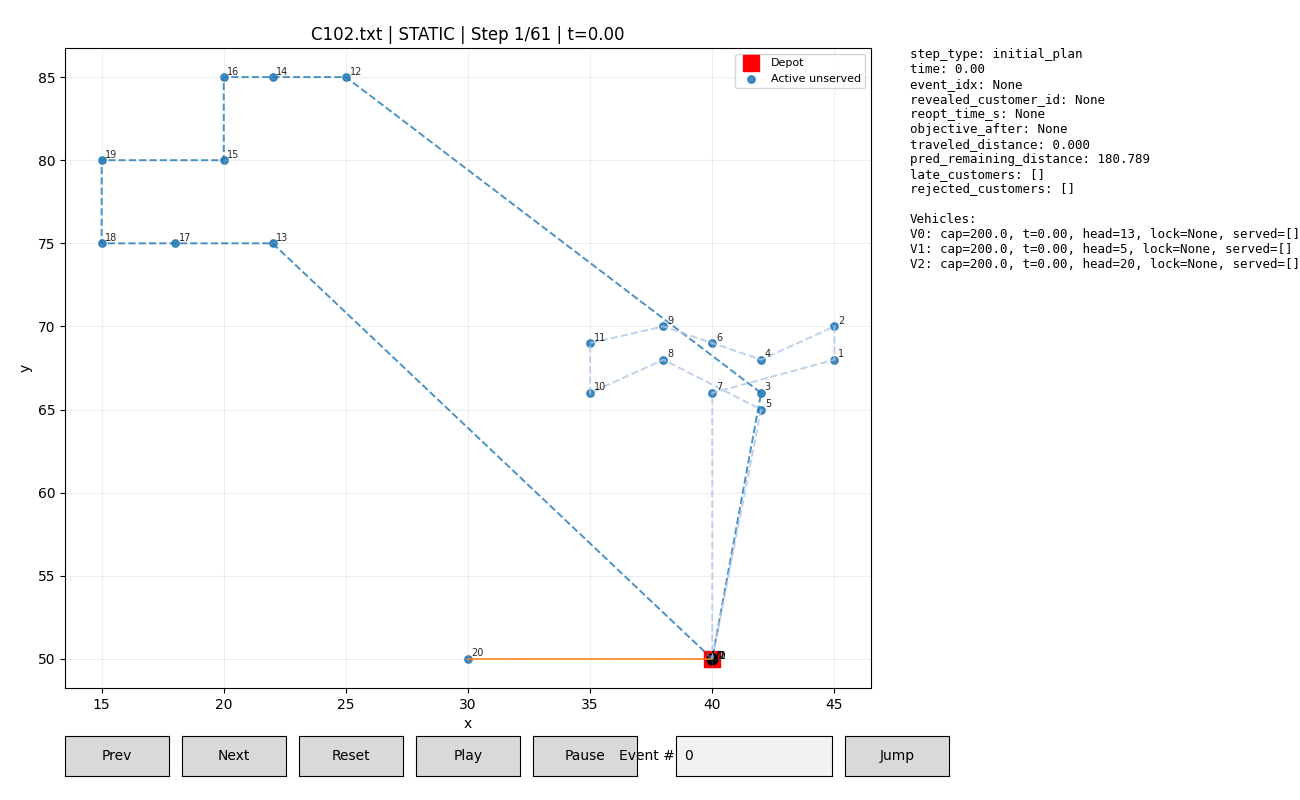

In [10]:
%matplotlib widget
from dvrptw_bench.viz.inspector import inspect_static
# inspect rl
inspect_static(instances[9], rl_solutions[9])